# Exploratory analysis — German solar, weather and price

Reads from the BigQuery `marts` and `staging` layers built by SQLMesh. Cleaning
and feature engineering already happened in SQL; this notebook asks whether the
result carries signal, and how hard the forecasting problem actually is.

Coverage is 2022-01-01 onward, bounded by the Open-Meteo forecast archive.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from smartgrid.config import get_settings
from smartgrid.viz import style
from smartgrid.warehouse import query

style.apply_style()
PROJECT = get_settings().require_project()

mart = query(f"SELECT * FROM `{PROJECT}.marts.mart_solar_features` ORDER BY utc_timestamp")
mart["local_datetime"] = pd.to_datetime(mart["local_datetime"])

print(f"{len(mart):,} hourly rows")
print(f"{mart['utc_timestamp'].min()} to {mart['utc_timestamp'].max()}")

summary_columns = [
    "solar_capacity_factor",
    "ghi_wm2_day_ahead",
    "tso_solar_forecast_capacity_factor",
]
mart[summary_columns].describe()

40,126 hourly rows
2022-01-01 00:00:00+00:00 to 2026-07-30 21:00:00+00:00


,solar_capacity_factor,ghi_wm2_day_ahead,tso_solar_forecast_capacity_factor
count,40126.000000,22162.000000,40126.000000
mean,0.089100,138.885899,0.092064
std,0.134604,209.403280,0.138434
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.003421,9.000000,0.004160
75%,0.144940,215.750000,0.151123
max,0.624688,884.000000,0.629944


## 1. What solar output looks like

Mean capacity factor across month and hour of day. This is a magnitude question,
so one hue from light to dark rather than a rainbow.

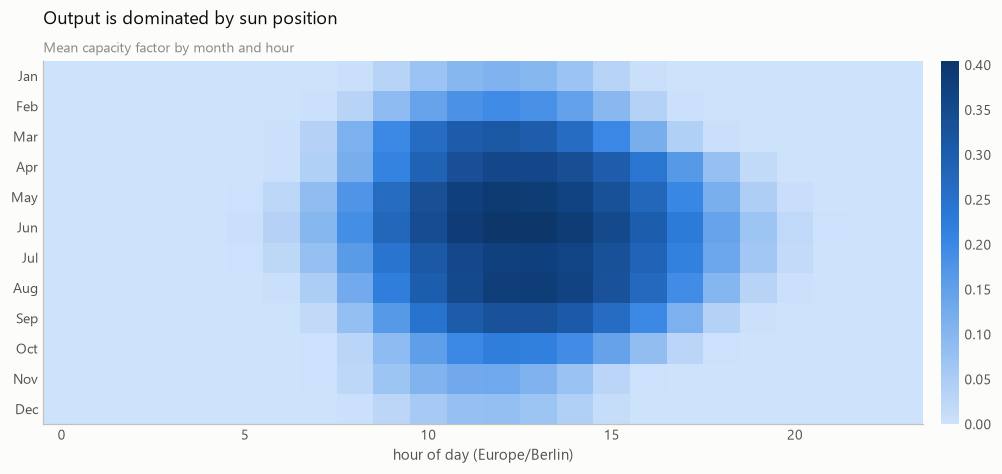

In [2]:
pivot = mart.pivot_table(
    index="month_of_year", columns="hour_of_day",
    values="solar_capacity_factor", aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(9, 4.2))
mesh = ax.pcolormesh(pivot.columns, pivot.index, pivot.to_numpy(),
                     cmap=style.sequential_cmap(), shading="nearest")
ax.set_xlabel("hour of day (Europe/Berlin)")
ax.set_yticks(range(1, 13))
ax.set_yticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.invert_yaxis()
ax.grid(False)
style.titled(ax, "Output is dominated by sun position",
             "Mean capacity factor by month and hour")
bar = fig.colorbar(mesh, ax=ax, pad=0.02)
bar.outline.set_visible(False)
bar.ax.tick_params(length=0, labelsize=9)
style.save(fig, "solar_capacity_factor_heatmap")
plt.show()

The shape is almost entirely determined by where the sun is. That part is
deterministic and a model gets it for free from calendar features. The forecasting
problem lives in the deviation from this surface — which is weather.

## 2. Why the target is normalised

Installed capacity nearly doubled over the window. Raw megawatts therefore carry a
deployment trend that has nothing to do with weather.

Deliberately three stacked panels rather than a dual-axis chart: aligning two
y-scales invents a relationship whose strength depends on where the axes are pinned.

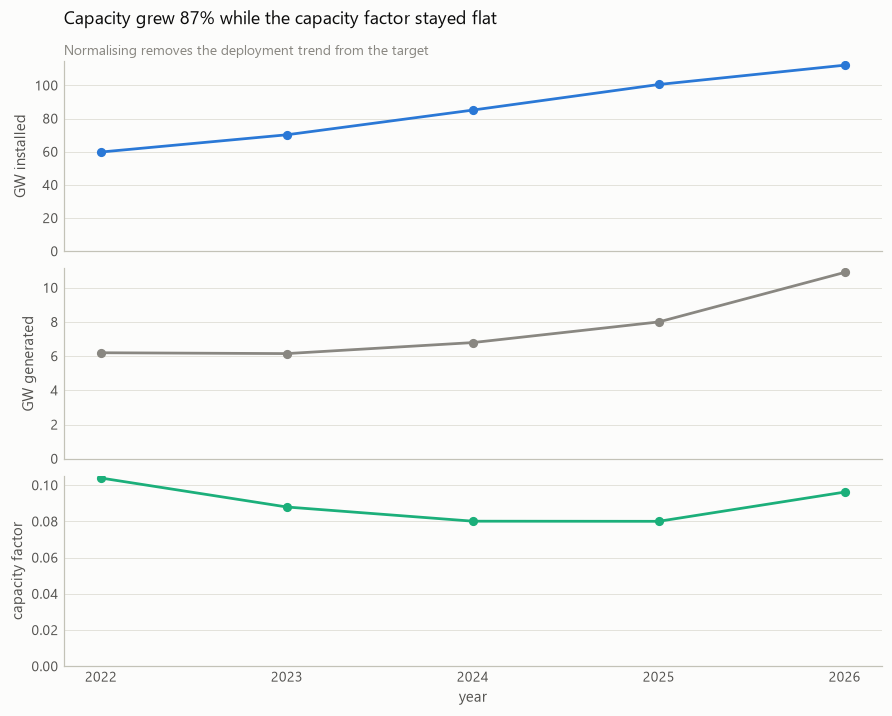

capacity growth      1.88x
capacity factor range 1.30x


In [3]:
yearly = mart.groupby(mart["local_datetime"].dt.year).agg(
    capacity_gw=("solar_ac_mw", lambda s: s.mean() / 1000),
    generation_gw=("solar_mw", lambda s: s.mean() / 1000),
    capacity_factor=("solar_capacity_factor", "mean"),
)

fig, axes = plt.subplots(3, 1, figsize=(8, 6.4), sharex=True)
for ax, (column, label, colour) in zip(axes, [
    ("capacity_gw", "GW installed", style.BLUE),
    ("generation_gw", "GW generated", style.INK_MUTED),
    ("capacity factor", "capacity factor", style.GREEN),
], strict=True):
    key = "capacity_factor" if column == "capacity factor" else column
    ax.plot(yearly.index, yearly[key], color=colour, marker="o")
    ax.set_ylabel(label)
    ax.set_ylim(0, None)

axes[2].set_xticks(yearly.index)
axes[2].set_xlabel("year")
style.titled(
    axes[0],
    "Capacity grew 87% while the capacity factor stayed flat",
    "Normalising removes the deployment trend from the target",
)
style.save(fig, "capacity_growth_vs_capacity_factor")
plt.show()

growth = yearly["capacity_gw"].iloc[-1] / yearly["capacity_gw"].iloc[0]
spread = yearly["capacity_factor"].max() / yearly["capacity_factor"].min()
print(f"capacity growth      {growth:.2f}x")
print(f"capacity factor range {spread:.2f}x")

## 3. How good is the day-ahead weather forecast?

Every weather column in the mart was issued a day before the hour it describes,
which is the lead a forecast gated at noon actually has. The staging layer also
keeps the archive's short-lead values, so the cost of that lead time is measurable
rather than assumed.

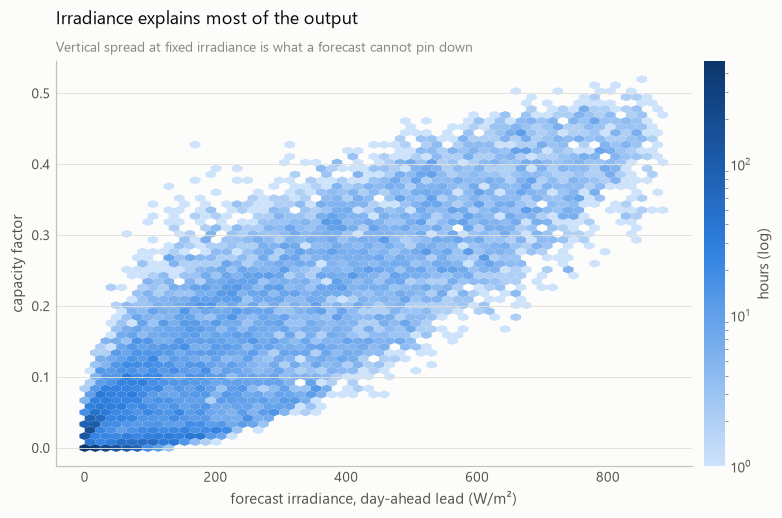

correlation with output, day-ahead lead : 0.8576
correlation with output, short lead     : 0.8599
mean absolute disagreement              : 40.9 W/m²


In [4]:
leads = query(f'''
    SELECT m.utc_timestamp, m.solar_capacity_factor,
           m.ghi_wm2_day_ahead, w.ghi_wm2 AS ghi_short_lead
    FROM `{PROJECT}.marts.mart_solar_features` AS m
    JOIN `{PROJECT}.staging.stg_weather` AS w USING (utc_timestamp)
    WHERE w.ghi_wm2 > 0
''')

fig, ax = plt.subplots(figsize=(7, 4.6))
hexes = ax.hexbin(leads["ghi_wm2_day_ahead"], leads["solar_capacity_factor"],
                  gridsize=55, bins="log", cmap=style.sequential_cmap(),
                  mincnt=1, linewidths=0)
ax.set_xlabel("forecast irradiance, day-ahead lead (W/m²)")
ax.set_ylabel("capacity factor")
style.titled(ax, "Irradiance explains most of the output",
             "Vertical spread at fixed irradiance is what a forecast cannot pin down")
bar = fig.colorbar(hexes, ax=ax, pad=0.02, label="hours (log)")
bar.outline.set_visible(False)
bar.ax.tick_params(length=0, labelsize=9)
style.save(fig, "irradiance_vs_output")
plt.show()

day_ahead_corr = leads["ghi_wm2_day_ahead"].corr(leads["solar_capacity_factor"])
short_corr = leads["ghi_short_lead"].corr(leads["solar_capacity_factor"])
gap = (leads["ghi_wm2_day_ahead"] - leads["ghi_short_lead"]).abs().mean()

print(f"correlation with output, day-ahead lead : {day_ahead_corr:.4f}")
print(f"correlation with output, short lead     : {short_corr:.4f}")
print(f"mean absolute disagreement              : {gap:.1f} W/m²")

The two leads disagree by around 50 W/m² on average, yet correlate with actual
output almost identically. A day of extra lead time adds noise without destroying
the signal.

That matters for honesty: using the short-lead values would be leakage, and it
turns out to buy almost nothing. The correct choice is close to free.

## 4. How hard is the problem?

Two weeks in June. Sun position is nearly identical across them, so any variation
is weather.

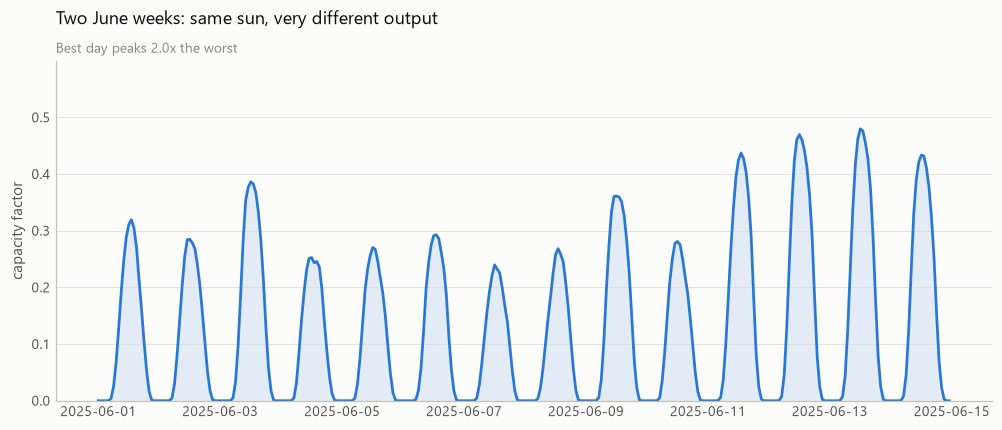

daily peak ranges 0.240 to 0.480


In [5]:
june = mart[(mart["local_datetime"] >= "2025-06-01")
            & (mart["local_datetime"] < "2025-06-15")]
style.require_data(june, "June 2025")

daily_peak = june.groupby(june["local_datetime"].dt.date)["solar_capacity_factor"].max()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(june["local_datetime"], june["solar_capacity_factor"], color=style.BLUE)
ax.fill_between(june["local_datetime"], june["solar_capacity_factor"],
                color=style.BLUE, alpha=0.12, linewidth=0)
ax.set_ylim(0, june["solar_capacity_factor"].max() * 1.25)
ax.set_ylabel("capacity factor")
style.titled(ax, "Two June weeks: same sun, very different output",
             f"Best day peaks {daily_peak.max()/daily_peak.min():.1f}x the worst")
style.save(fig, "june_daily_variability")
plt.show()

print(f"daily peak ranges {daily_peak.min():.3f} to {daily_peak.max():.3f}")

## 5. The benchmark

`tso_solar_forecast_mw` is what the transmission operators published for the same
hour. It is the bar this project's models are measured against — a real operational
forecast, not a naive baseline.

Scored on daylight hours only. Solar output is exactly zero at night and every
method gets that right for free, so including those hours flatters everything
equally.

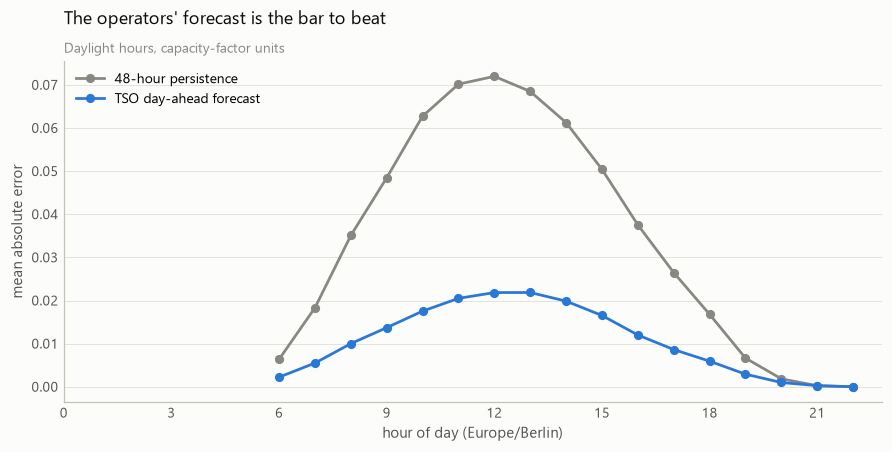

TSO forecast MAE      0.0131
48h persistence MAE   0.0424
ratio                 3.2x


In [6]:
daylight = mart[(mart["ghi_wm2_day_ahead"] > 0)
                & mart["tso_solar_forecast_capacity_factor"].notna()
                & mart["capacity_factor_lag_48h"].notna()].copy()

daylight["tso_error"] = (daylight["tso_solar_forecast_capacity_factor"]
                         - daylight["solar_capacity_factor"]).abs()
daylight["lag_error"] = (daylight["capacity_factor_lag_48h"]
                         - daylight["solar_capacity_factor"]).abs()

by_hour = daylight.groupby("hour_of_day")[["tso_error", "lag_error"]].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_hour.index, by_hour["lag_error"], color=style.INK_MUTED,
        marker="o", label="48-hour persistence")
ax.plot(by_hour.index, by_hour["tso_error"], color=style.BLUE,
        marker="o", label="TSO day-ahead forecast")
ax.set_xlabel("hour of day (Europe/Berlin)")
ax.set_ylabel("mean absolute error")
ax.set_xticks(range(0, 24, 3))
ax.legend(loc="upper left")
style.titled(ax, "The operators' forecast is the bar to beat",
             "Daylight hours, capacity-factor units")
style.save(fig, "tso_benchmark_by_hour")
plt.show()

print(f"TSO forecast MAE      {daylight['tso_error'].mean():.4f}")
print(f"48h persistence MAE   {daylight['lag_error'].mean():.4f}")
print(f"ratio                 {daylight['lag_error'].mean() / daylight['tso_error'].mean():.1f}x")

## 6. Do the features carry signal?

Correlation with the target, but measured carefully.

Across all daylight hours, every variable that tracks time of day scores well:
at dawn and dusk output is near zero and at noon it is high, so the daily cycle
alone produces a strong correlation whether or not a feature says anything about
*this particular day*. On that measure a 48-hour lag outranks the irradiance
forecast, which would be a misleading conclusion.

Restricting to midday hours holds sun position roughly constant, so what remains
is the ability to tell a clear day from an overcast one. That is the part a
forecast has to get right.

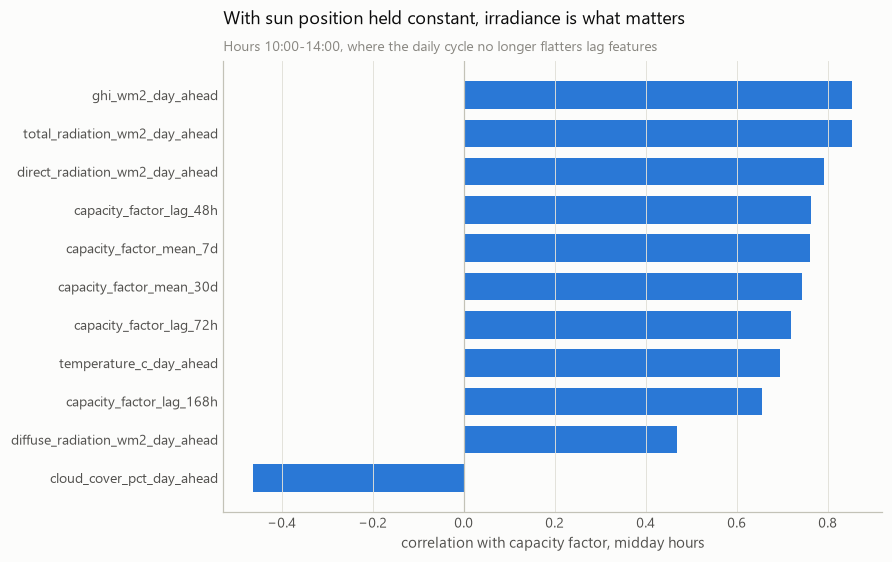

,all_daylight,midday_only,change
ghi_wm2_day_ahead,0.857527,0.853023,-0.004504
total_radiation_wm2_day_ahead,0.857527,0.853023,-0.004504
direct_radiation_wm2_day_ahead,0.774927,0.792295,0.017368
capacity_factor_lag_48h,0.880815,0.763485,-0.117329
capacity_factor_mean_7d,0.357460,0.760647,0.403188
capacity_factor_mean_30d,0.347076,0.743585,0.396509
capacity_factor_lag_72h,0.858123,0.719527,-0.138596
temperature_c_day_ahead,0.394038,0.695044,0.301005
capacity_factor_lag_168h,0.825427,0.656160,-0.169267
diffuse_radiation_wm2_day_ahead,0.678174,0.467794,-0.210380


In [7]:
features = [
    "ghi_wm2_day_ahead", "direct_radiation_wm2_day_ahead",
    "diffuse_radiation_wm2_day_ahead", "total_radiation_wm2_day_ahead",
    "temperature_c_day_ahead", "cloud_cover_pct_day_ahead",
    "capacity_factor_lag_48h", "capacity_factor_lag_72h",
    "capacity_factor_lag_168h", "capacity_factor_mean_7d",
    "capacity_factor_mean_30d",
]

midday = daylight[daylight["hour_of_day"].between(10, 14)]

all_hours = daylight[features].corrwith(daylight["solar_capacity_factor"])
midday_only = midday[features].corrwith(midday["solar_capacity_factor"])
ranked = midday_only.sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ranked.index, ranked.to_numpy(), color=style.BLUE, height=0.72)
ax.axvline(0, color=style.AXIS, linewidth=0.8)
ax.set_xlabel("correlation with capacity factor, midday hours")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
style.titled(ax, "With sun position held constant, irradiance is what matters",
             "Hours 10:00-14:00, where the daily cycle no longer flatters lag features")
style.save(fig, "feature_correlation_midday")
plt.show()

comparison = pd.DataFrame({"all_daylight": all_hours, "midday_only": midday_only})
comparison["change"] = comparison["midday_only"] - comparison["all_daylight"]
comparison.reindex(comparison["midday_only"].abs().sort_values(ascending=False).index)

## 7. Prices

Not needed for the solar forecast, but it drives the battery optimiser later, so
worth understanding now.

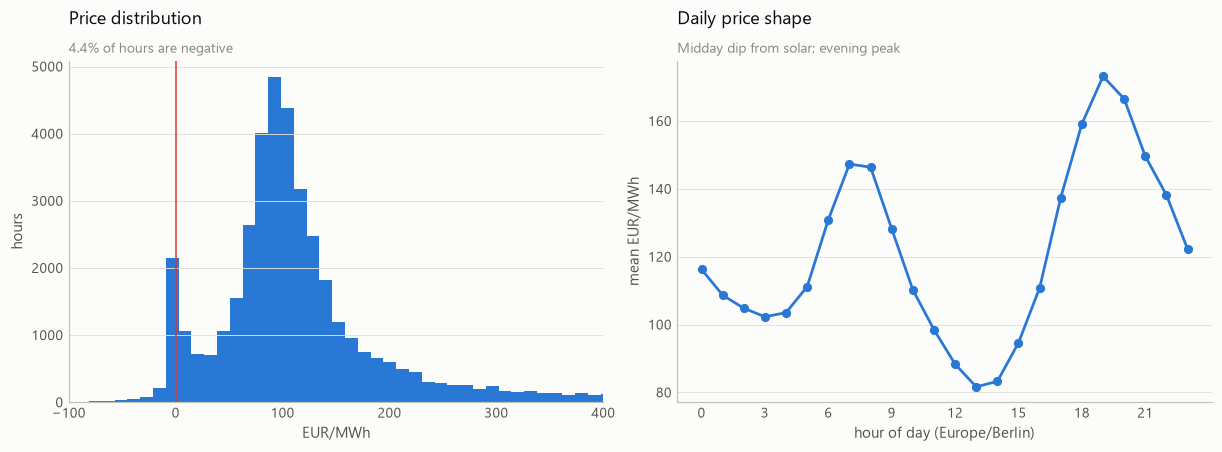

negative hours: 1,780 of 40,127
spread between cheapest and dearest hour of the day: 91.5 EUR/MWh


In [8]:
price = query(f'''
    SELECT utc_timestamp, price_eur_mwh,
           EXTRACT(HOUR FROM DATETIME(utc_timestamp, 'Europe/Berlin')) AS hour_of_day
    FROM `{PROJECT}.staging.stg_price`
    WHERE price_eur_mwh IS NOT NULL
''')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(price["price_eur_mwh"], bins=120, color=style.BLUE)
axes[0].axvline(0, color=style.CRITICAL, linewidth=1)
axes[0].set_xlabel("EUR/MWh")
axes[0].set_ylabel("hours")
axes[0].set_xlim(-100, 400)
negative_share = (price["price_eur_mwh"] < 0).mean()
style.titled(axes[0], "Price distribution",
             f"{negative_share:.1%} of hours are negative")

shape = price.groupby("hour_of_day")["price_eur_mwh"].mean()
axes[1].plot(shape.index, shape.to_numpy(), color=style.BLUE, marker="o")
axes[1].set_xlabel("hour of day (Europe/Berlin)")
axes[1].set_ylabel("mean EUR/MWh")
axes[1].set_xticks(range(0, 24, 3))
style.titled(axes[1], "Daily price shape",
             "Midday dip from solar; evening peak")
style.save(fig, "price_distribution_and_shape")
plt.show()

print(f"negative hours: {(price['price_eur_mwh'] < 0).sum():,} of {len(price):,}")
print(f"spread between cheapest and dearest hour of the day: "
      f"{shape.max() - shape.min():.1f} EUR/MWh")

## What this establishes

| Finding | Consequence |
|---|---|
| Output is dominated by sun position | Calendar and geometry features are free; the problem is the deviation |
| Capacity grew 87%, capacity factor flat | Normalising by AC capacity was necessary, not cosmetic |
| Day-ahead and short-lead weather correlate almost identically with output | Using the honest lead costs very little |
| Consecutive June days differ severalfold | Weather is the whole problem, and it is genuinely hard |
| TSO forecast is ~3x better than 48-hour persistence | The benchmark is a real bar, not a strawman |
| Correlation across all daylight hours is inflated by the daily cycle | Feature importance has to control for sun position, or lags look better than they are |
| At midday, irradiance separates from the lags | Weather is the discriminating feature; lags and calendar are support |
| ~5% of price hours are negative, with a strong daily shape | The battery optimiser has real arbitrage to work with |

Next: fit a model on these features and score it against the TSO forecast on
daylight hours, using walk-forward validation.